### SETUP

In [2]:
import pandas as np
import pandas as pd
import matplotlib.pyplot as plt

## EDA

In [3]:
# load train csv
train_df = pd.read_csv('dataset/drugsComTrain_raw.csv')

# load test csv
test_df = pd.read_csv('dataset/drugsComTest_raw.csv')

### DATA OVERVIEW

CHECK NUM OF SAMPLES IN EACH DATASTET:

In [4]:
print(f'TRAIN DATASET LENGTH: {len(train_df)} \nTEST DATASET LENGTH: {len(test_df)}')

TRAIN DATASET LENGTH: 161297 
TEST DATASET LENGTH: 53766


CHECK COLUMNS AND DATATYPE:

In [5]:
print('TRAIN DATASET:')
train_df.dtypes

TRAIN DATASET:


uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

In [6]:
print('TEST DATASET:')
test_df.dtypes

TEST DATASET:


uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

CHECK CONTENT:

In [7]:
print('TRAIN DATASET:') 
train_df.head(5)

TRAIN DATASET:


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [8]:
print(f'TEST DATASET:')
test_df.head(5)

TEST DATASET:


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


### MERGE DATASETS

Since we will be training based on the scores, it would be best if we stratified the train test split. So, if IDs are unique, we may merge the datasets

CHECK IDs

In [9]:
print(f"TRAIN UNIQUE IDs: {len(train_df['uniqueID'].unique())}/{len(train_df)}")
print(f"TEST UNIQUE IDs: {len(test_df['uniqueID'].unique())}/{len(test_df)}")

TRAIN UNIQUE IDs: 161297/161297
TEST UNIQUE IDs: 53766/53766


CHECK IF TEST IDs APPEAR IN TRAIN:

In [ ]:
test_ids_in_train = train_df[train_df['uniqueID'].isin(test_df['uniqueID'])]
print(f"Num TEST ID's IN TRAIN: {len(test_ids_in_train)}")

Num TEST ID's IN TRAIN: 0


Since there are no overlapping ID's, we can merge the train and test dfs into a single dataset:

In [18]:
# concatenate the dfs
dataset = pd.concat([train_df, test_df], axis = 0)

# save new df as csv
dataset.to_csv("dataset/drugsCOM_raw.csv")

In [19]:
print(f"LEN DATASET: {len(dataset)}")

LEN DATASET: 215063


### DATA INSPECTION

#### RATINGS

STUDY RATING DISTRIBUTION

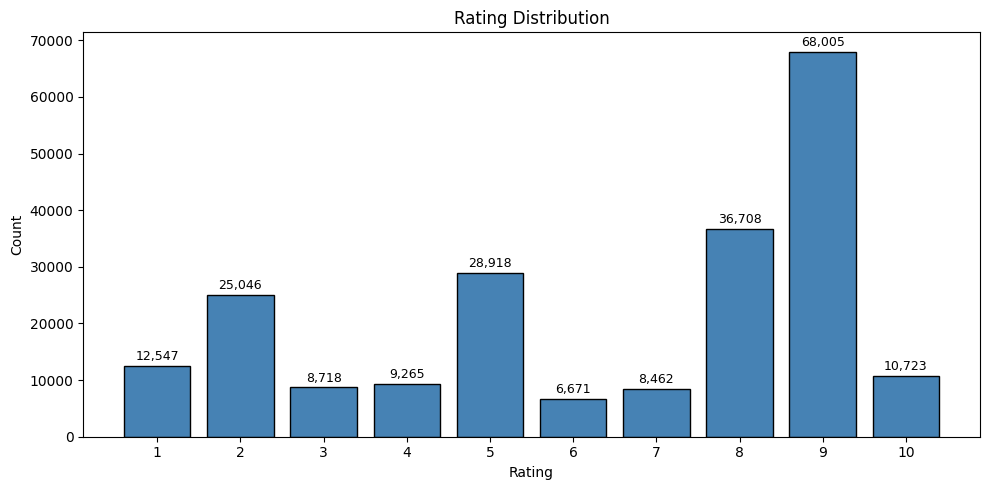

In [ ]:
# plot rating distribution

scores = dataset['rating']

plt.figure(figsize=(10, 5))
bars = plt.bar(scores.unique(), scores.value_counts(), color='steelblue', edgecolor='black')

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')

# add num samples for each val
for bar in bars: 
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.xticks(scores.unique())
plt.tight_layout()
plt.show()